In [3]:
data= pd.read_csv("housing.csv")


In [2]:
import pandas as pd

In [4]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [5]:
import numpy as np
data["income_cat"]=pd.cut(data["median_income"], bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],labels=[1, 2, 3, 4, 5])

In [6]:
from sklearn.model_selection import StratifiedShuffleSplit

# Assume income_cat is a column in the dataset created from median_income
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(data, data["income_cat"]):
    train_set = data.loc[train_index]
    test_set = data.loc[test_index]

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

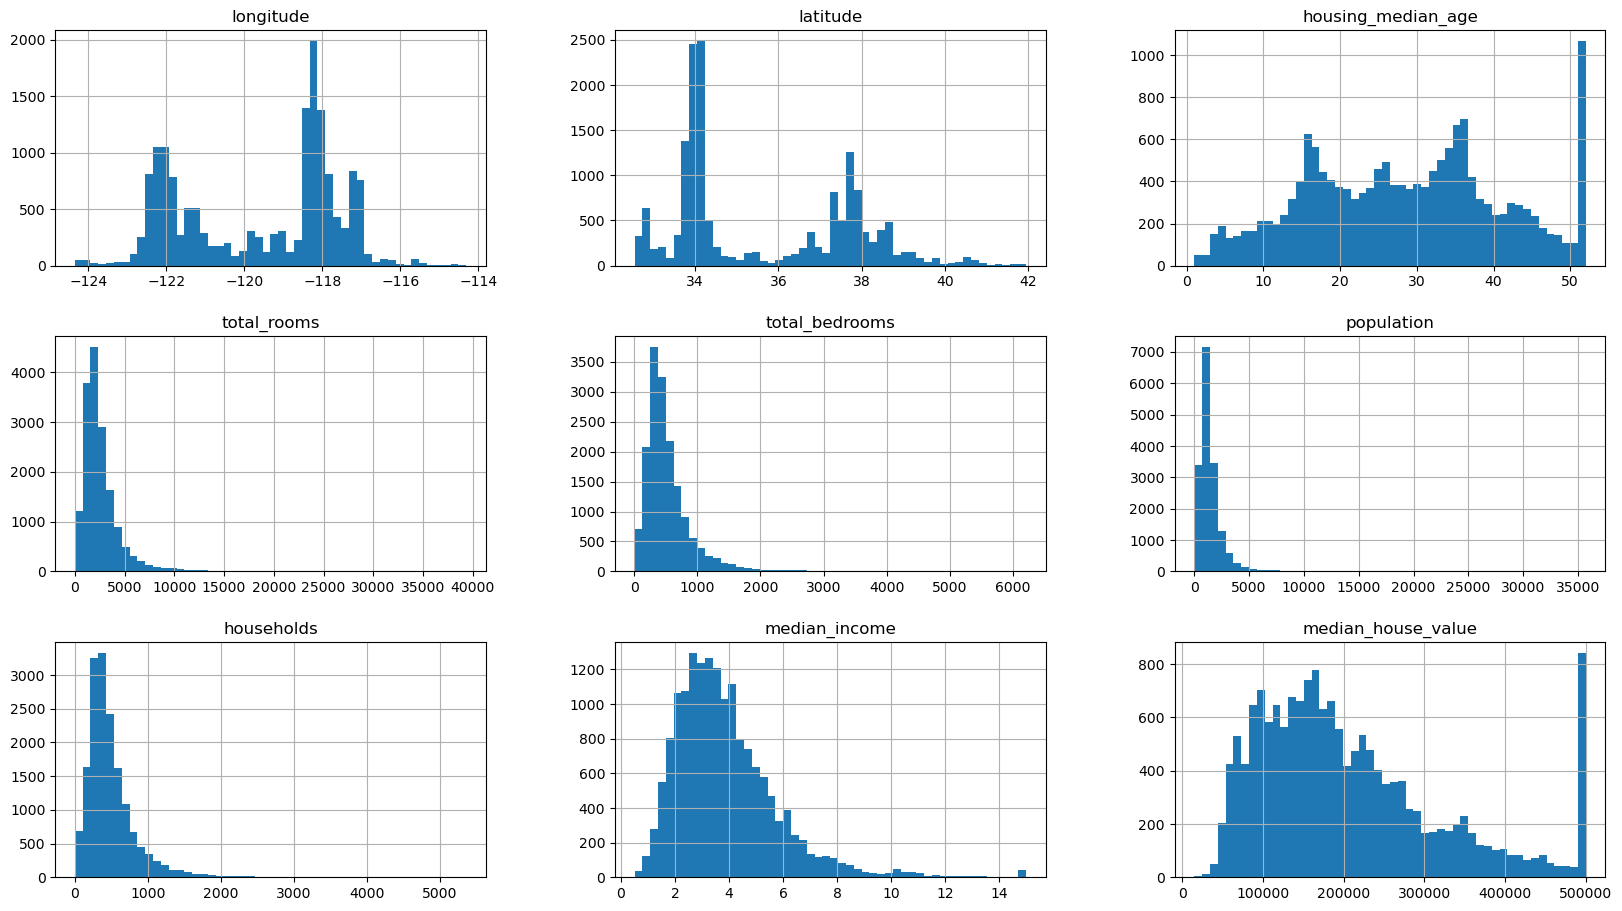

In [10]:
train_set.hist(bins=50, figsize=(20,11))

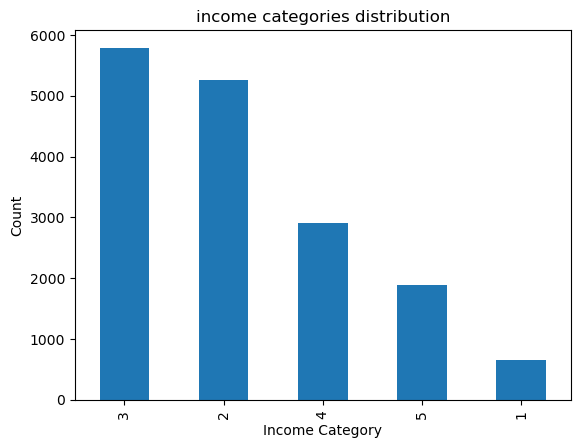

In [13]:
import matplotlib.pyplot as plt
train_set["income_cat"].value_counts().plot.bar()
plt.title("income categories distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.show()

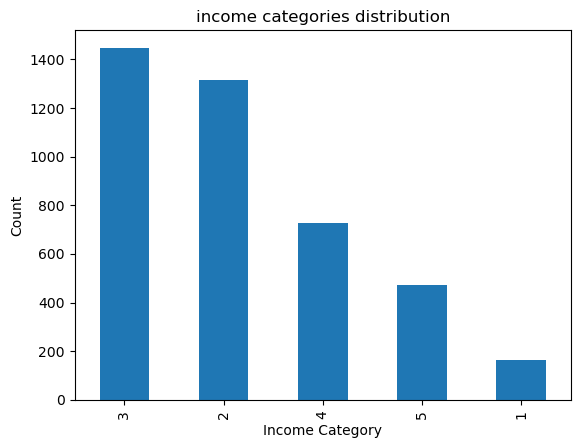

In [14]:
test_set["income_cat"].value_counts().plot.bar()
plt.title("income categories distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.show()

In [ ]:
test_set.drop(columns=["income_cat"], inplace = True)
train_set.drop(columns=["income_cat"], inplace=True)


In [34]:
df = train_set.copy()

In [35]:
import matplotlib.pyplot as plt

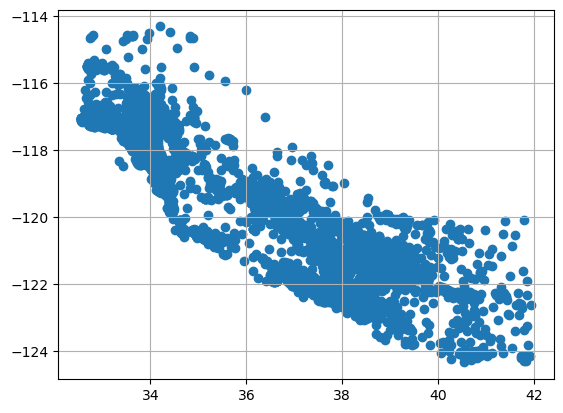

In [58]:
x = df["longitude"]
y = df["latitude"]
plt.scatter(y,x)
plt.grid(True)

In [59]:
import seaborn as sns

ValueError: could not convert string to float: 'NEAR BAY'

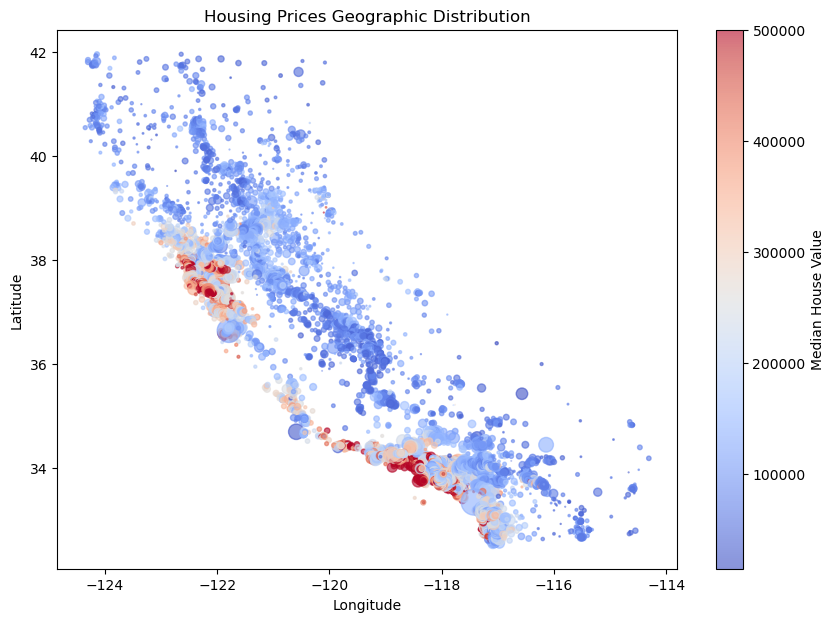

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    x=data["longitude"], 
    y=data["latitude"], 
    c=data["median_house_value"], # This colors the points by house value
    cmap="coolwarm",              # Choose your color map
    s=data["population"]/100,     # Optional: scale circle size by population
    alpha=0.6
)

# Add a color bar to the side so you know what prices the colors represent
plt.colorbar(scatter, label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Housing Prices Geographic Distribution")
plt.show()

In [77]:
import matplotlib.pyplot as plt
plt.scatter(df2)

TypeError: scatter() missing 1 required positional argument: 'y'

In [67]:
df2= df.copy()
# df.corr()

In [71]:
df3=df2.drop(columns=["ocean_proximity"])

In [73]:
df3.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781
population,0.108071,-0.115290,-0.298737,0.855103,0.876324,1.000000,0.904639,0.002421,-0.026882
households,0.063146,-0.077765,-0.306473,0.918396,0.980167,0.904639,1.000000,0.010869,0.064590
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009643,0.002421,0.010869,1.000000,0.687151
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047781,-0.026882,0.064590,0.687151,1.000000


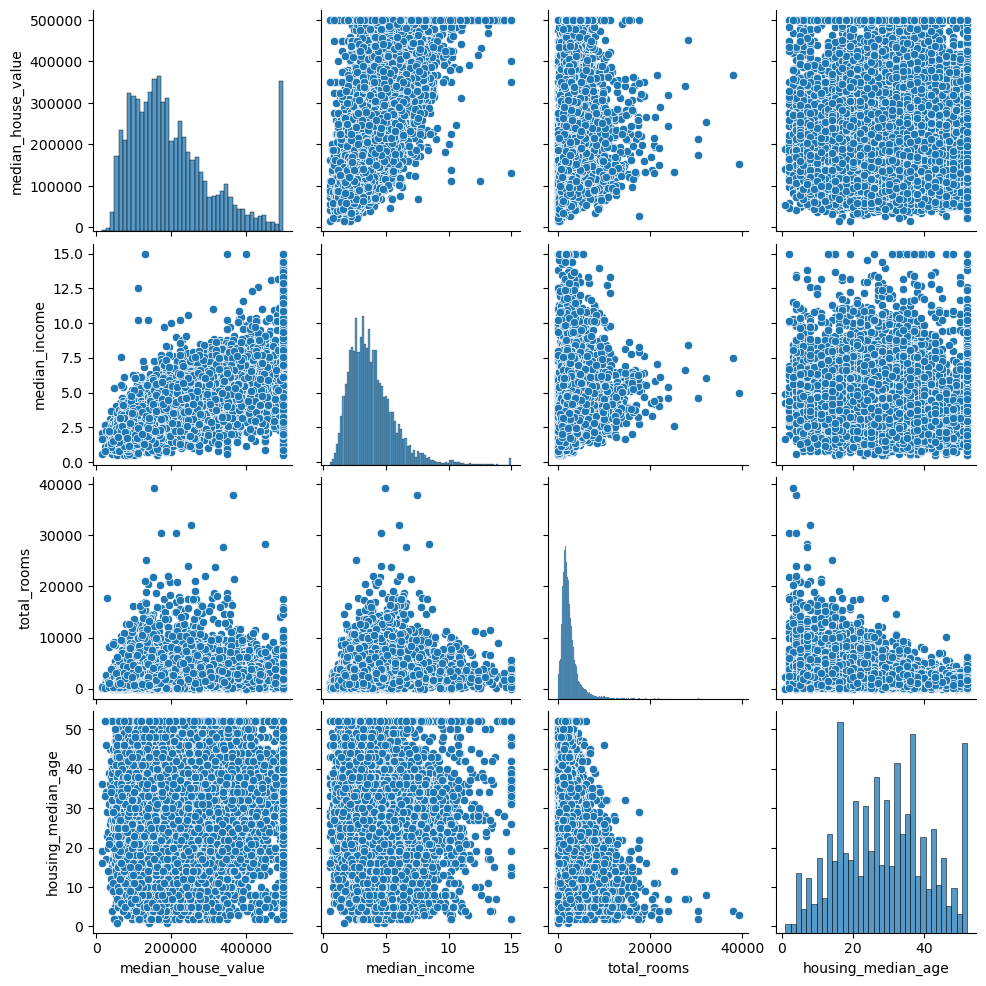

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# Choose a few important columns
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]

# Plot using seaborn
sns.pairplot(df3[attributes])
plt.show()

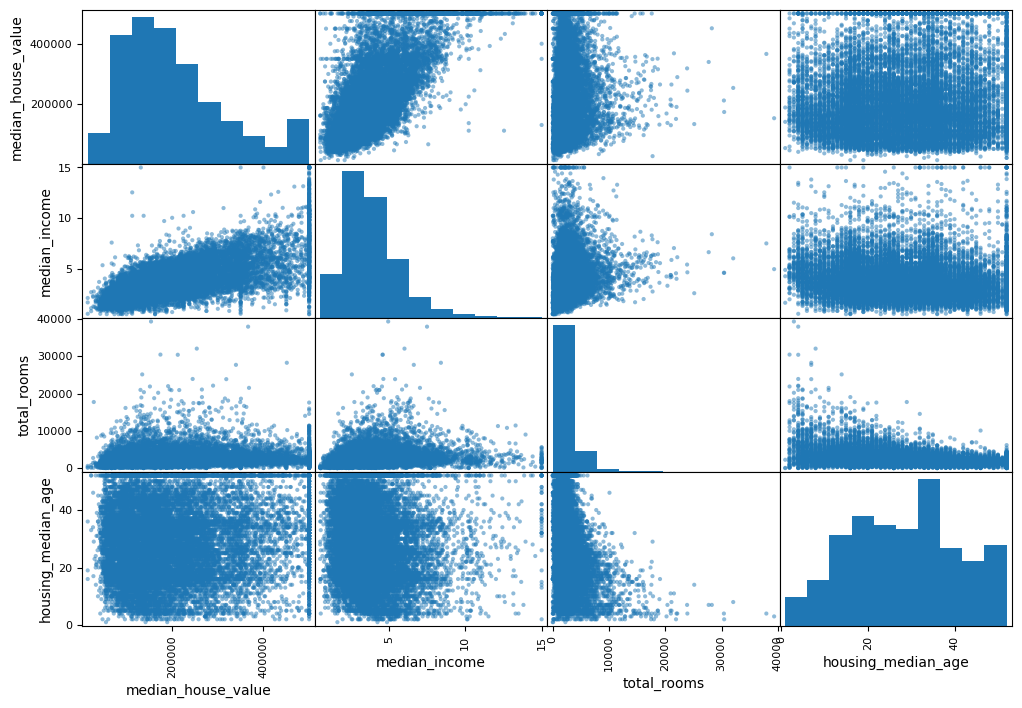

In [75]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

# Choose a few important columns to focus on
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]

# Plot the scatter matrix for just those columns using df3
scatter_matrix(df3[attributes], figsize=(12, 8))
plt.show()

In [ ]:
fo